# Creating Fake data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## Function copied from grading_rubric.ipynb file

In [2]:
def score_ph(ph):
    """pH 5.5-7.5 = perfect. Outside 4.5-9.0 = zero."""
    ph = float(ph)
    if ph <= 4.5 or ph >= 9.0:
        return 0.0
    if ph < 5.5:
        return (ph - 4.5) / (5.5 - 4.5)
    if ph <= 7.5:
        return 1.0
    return 1.0 - (ph - 7.5) / (9.0 - 7.5)

def score_n(n_total):
    """More available N is better, up to 10 mg/kg."""
    return min(1.0, max(0.0, float(n_total) / 10.0))

def score_k(k):
    """More K is better, up to 150 mg/kg."""
    return min(1.0, max(0.0, float(k) / 150.0))

WEIGHTS = {"pH": 0.50, "N": 0.35, "K": 0.15}

def score_soil(ph, n_total, k):
    """
    Takes pH, total available N (NH4 + NO3), and K.
    Returns final habitability score between 0.0 and 1.0.
    """
    subs = {
        "pH": score_ph(ph),
        "N":  score_n(n_total),
        "K":  score_k(k),
    }
    final = sum(subs[feat] * WEIGHTS[feat] for feat in subs)
    return round(final, 4)

In [3]:
REAL_SOILS = {
    "Earth": {"pH": 8.3, "N_total": 0.5 + 4.2, "K": 4.7},
    "Moon":  {"pH": 9.6, "N_total": 0.3 + 4.2, "K": 27.0},
    "Mars":  {"pH": 7.3, "N_total": 3.9 + 2.1, "K": 138.0},
}

print("Real soil values (starting points for synthetic generation):")
print()
print(f"{'Soil':8} {'pH':>6} {'N_total (mg/kg)':>17} {'K (mg/kg)':>11}  Real rubric score")
print("-" * 60)
for soil, vals in REAL_SOILS.items():
    real_score = score_soil(vals["pH"], vals["N_total"], vals["K"])
    print(f"{soil:8} {vals['pH']:>6.1f} {vals['N_total']:>17.1f} "
          f"{vals['K']:>11.1f}  {real_score:.3f}")


Real soil values (starting points for synthetic generation):

Soil         pH   N_total (mg/kg)   K (mg/kg)  Real rubric score
------------------------------------------------------------
Earth       8.3               4.7         4.7  0.403
Moon        9.6               4.5        27.0  0.184
Mars        7.3               6.0       138.0  0.848


## Defining realistic bounds
constraints should be put such as:
- We allow ±30% variation around each real value (a reasonable batch-to-batch variation for simulants)
- We also apply **hard physical limits** — pH can't go below 0 or above 14
- We clip any out-of-range values so nothing impossible slips throug

In [10]:
BOUNDS = {
    "Earth": {
        "pH":      (6.5,  9.5),   
        "N_total": (1.0,  8.0),   
        "K":       (1.0, 15.0),   
    },
    "Moon": {
        "pH":      (8.5, 11.0),   
        "N_total": (1.0,  8.0),  
        "K":       (5.0, 55.0),   
    },
    "Mars": {
        "pH":      (6.0,  8.5),  
        "N_total": (2.0, 12.0),  
        "K":       (60.0, 220.0), 
    },
}


## Generating synthetic soils

In [11]:
N_SAMPLES = 5000  

rows = []

for soil_name, bounds in BOUNDS.items():
    phs      = np.random.uniform(bounds["pH"][0],      bounds["pH"][1],      N_SAMPLES)
    n_totals = np.random.uniform(bounds["N_total"][0], bounds["N_total"][1], N_SAMPLES)
    ks       = np.random.uniform(bounds["K"][0],       bounds["K"][1],       N_SAMPLES)

    for ph, n_total, k in zip(phs, n_totals, ks):
        score = score_soil(ph, n_total, k)
        rows.append({
            "source_soil":       soil_name,
            "pH":                round(ph, 3),
            "N_total_mgkg":      round(n_total, 3),
            "K_mgkg":            round(k, 3),
            "habitability_score": score,
        })

df_synth = pd.DataFrame(rows)

print(f"Generated {len(df_synth):,} synthetic soil samples")
print()
print("First 10 rows:")
df_synth.head(10)

Generated 15,000 synthetic soil samples

First 10 rows:


,source_soil,pH,N_total_mgkg,K_mgkg,habitability_score
0,Earth,7.490,6.931,2.238,0.7448
1,Earth,8.950,4.462,1.201,0.1740
2,Earth,9.483,2.368,11.282,0.0942
3,Earth,9.022,6.156,4.664,0.2201
4,Earth,7.538,3.931,13.287,0.6381
5,Earth,8.634,5.162,8.502,0.3113
6,Earth,8.102,1.751,7.699,0.3684
7,Earth,8.860,5.421,11.819,0.2484
8,Earth,6.959,3.615,11.375,0.6379
9,Earth,8.414,3.339,10.860,0.3229


In [7]:
print("Score summary by soil type:")
print()
summary = df_synth.groupby("source_soil")["habitability_score"].agg(
    count="count",
    mean="mean",
    min="min",
    max="max",
).round(3)
print(summary)

print()
real_scores = {s: score_soil(v["pH"], v["N_total"], v["K"])
               for s, v in REAL_SOILS.items()}
print("Real soil scores (for comparison):")
for s, sc in real_scores.items():
    print(f"  {s}: {sc:.3f}")

print()
mars_mean  = df_synth[df_synth.source_soil=="Mars"]["habitability_score"].mean()
earth_mean = df_synth[df_synth.source_soil=="Earth"]["habitability_score"].mean()
moon_mean  = df_synth[df_synth.source_soil=="Moon"]["habitability_score"].mean()
correct    = mars_mean > earth_mean > moon_mean
print(f"Ranking matches Mars > Earth > Moon: {'✓ YES' if correct else '✗ NO'}")


Score summary by soil type:

             count   mean    min    max
source_soil                            
Earth         5000  0.456  0.041  0.794
Mars          5000  0.795  0.346  1.000
Moon          5000  0.206  0.043  0.489

Real soil scores (for comparison):
  Earth: 0.403
  Moon: 0.184
  Mars: 0.848

Ranking matches Mars > Earth > Moon: ✓ YES


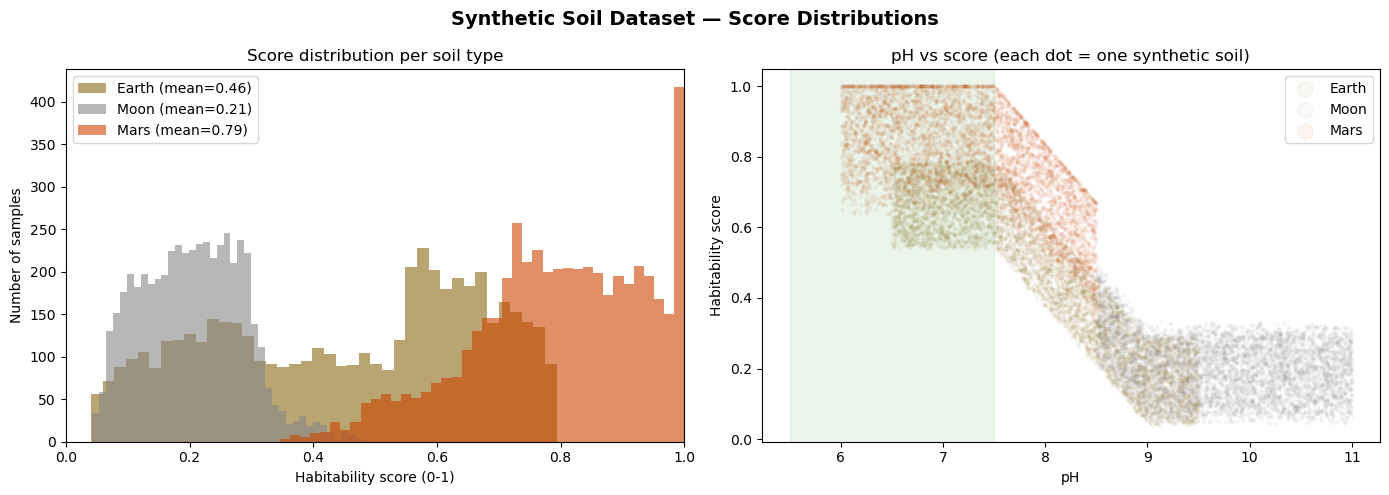

Chart saved as synthetic_distributions.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Synthetic Soil Dataset — Score Distributions", fontsize=14, fontweight="bold")

colors = {"Earth": "#8B6914", "Moon": "#888888", "Mars": "#CC4400"}

for soil in ["Earth", "Moon", "Mars"]:
    subset = df_synth[df_synth.source_soil == soil]["habitability_score"]
    axes[0].hist(subset, bins=40, alpha=0.6, color=colors[soil],
                 label=f"{soil} (mean={subset.mean():.2f})", edgecolor="none")

axes[0].set_xlabel("Habitability score (0-1)")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Score distribution per soil type")
axes[0].legend()
axes[0].set_xlim(0, 1)

# ── right: scatter — pH vs score, coloured by soil ───────────────────
for soil in ["Earth", "Moon", "Mars"]:
    subset = df_synth[df_synth.source_soil == soil]
    axes[1].scatter(subset["pH"], subset["habitability_score"],
                    alpha=0.05, s=5, color=colors[soil], label=soil)

axes[1].set_xlabel("pH")
axes[1].set_ylabel("Habitability score")
axes[1].set_title("pH vs score (each dot = one synthetic soil)")
axes[1].legend(markerscale=5)
axes[1].axvspan(5.5, 7.5, alpha=0.08, color="green", label="Optimal pH zone")

plt.tight_layout()
plt.savefig("synthetic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as synthetic_distributions.png")


In [9]:
output_path = "synthetic_soils.csv"
df_synth.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df_synth.shape}")
print()
print("Columns:")
for col in df_synth.columns:
    print(f"  {col}")


Saved: synthetic_soils.csv
Shape: (15000, 5)

Columns:
  source_soil
  pH
  N_total_mgkg
  K_mgkg
  habitability_score
